Simulation Parameters:
# disk_fill_phase_0=0.07511737089201878, res2d=100, res3d=6, mode=faconly, fac_r=[0], fac_long=[0], fac_lat=[0], fac_band=True, fac_band_low=[57, -90], fac_band_high=[90, -57], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03, hd_ld_file=test_phot.txt, fac_ld_file=test_fac_200G.txt
 
Loaded 972 files
Stacked shape (Wavelength, Phase, H, W): (972, 1, 100, 100)


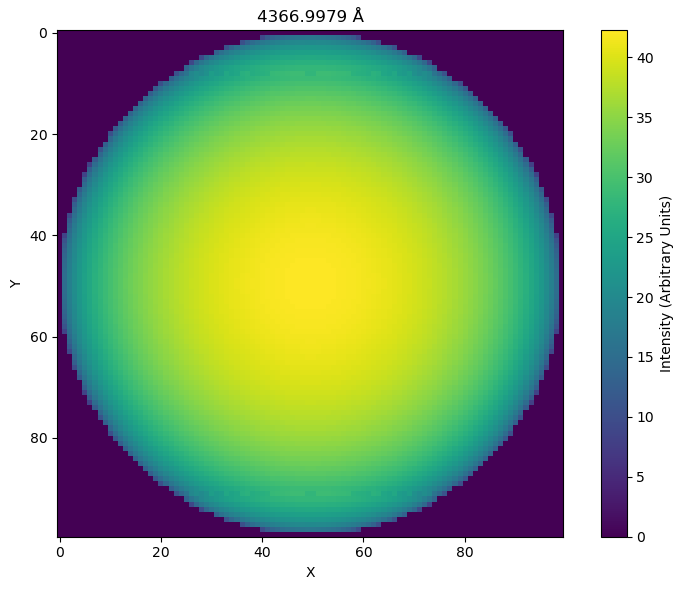

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


directory = './1_200G_4366.9979_4383.9923_facrandom_n10_fill0.51_seed12345_v4000_i90'
directory = './1_200G_4366.9979_4383.9923_facbands_-5to+5_discfill0.07_area_n59_got0.075_rot0_seed12345_v4000_i90'
directory = './1_200G_4366.9979_4383.9923_band_lat57_90_v4000'
#band
#directory = './1_4376.5109_4377.4913_band_lat45_90_v4000'




# print the header of the first file to get the simulation parameters
first_csv = next(Path('.').glob(f'{directory}/wavelength_shifts_inp*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip())
        print(' ')
else:
    print("No .csv files found to read the header from.")

# Find all intensity-map files
npy_files = sorted(Path('.').glob(f'{directory}/disk_inp*.npy'))
if not npy_files:
    raise FileNotFoundError("No files found matching pattern: disk_inp*.npy")

def parse_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.npy$', p.name)
    return float(m.group(1)) if m else np.nan

# Load all files into a dict: {wavelength: array}
intensity_maps = {}
for f in npy_files:
    wl = parse_wavelength(f)
    intensity_maps[wl] = np.load(f)

print(f"Loaded {len(intensity_maps)} files")
# for wl in sorted(intensity_maps):
#     print(f"  {wl}: shape={intensity_maps[wl].shape}")

# Optional: stack to one array if all shapes are identical
shapes = {arr.shape for arr in intensity_maps.values()}
if len(shapes) == 1:
    wavelengths = np.array(sorted(intensity_maps.keys()))
    all_intensity_maps = np.stack([intensity_maps[wl] for wl in wavelengths], axis=0)
    # all_intensity_maps shape: (num_wavelengths, num_phases, H, W)
    print("Stacked shape (Wavelength, Phase, H, W):", all_intensity_maps.shape)
else:
    print("Shapes differ across files; kept as dictionary in 'intensity_maps'.")


# Quick plot for one wavelength (first one) and one phase (idx=0)
plot_wl = sorted(intensity_maps.keys())[0]
idx = 0

plt.figure(figsize=(8, 6))
img_data = intensity_maps[plot_wl][idx]
im = plt.imshow(img_data, cmap='viridis')
plt.title(f'{plot_wl} Å')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im, label='Intensity (Arbitrary Units)')
plt.tight_layout()
plt.savefig('intensity_map_single.png', dpi=300, bbox_inches='tight')
plt.show()

Simulation Parameters:
# disk_fill_phase_0=0.07772561293688054, res2d=100, res3d=4, mode=faconly, fac_r=[0], fac_long=[0], fac_lat=[0], fac_band=True, fac_band_low=[-2.5], fac_band_high=[2.5], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03
 
Loaded 57 files
Stacked shape (Wavelength, Phase, H, W): (57, 1, 100, 100)


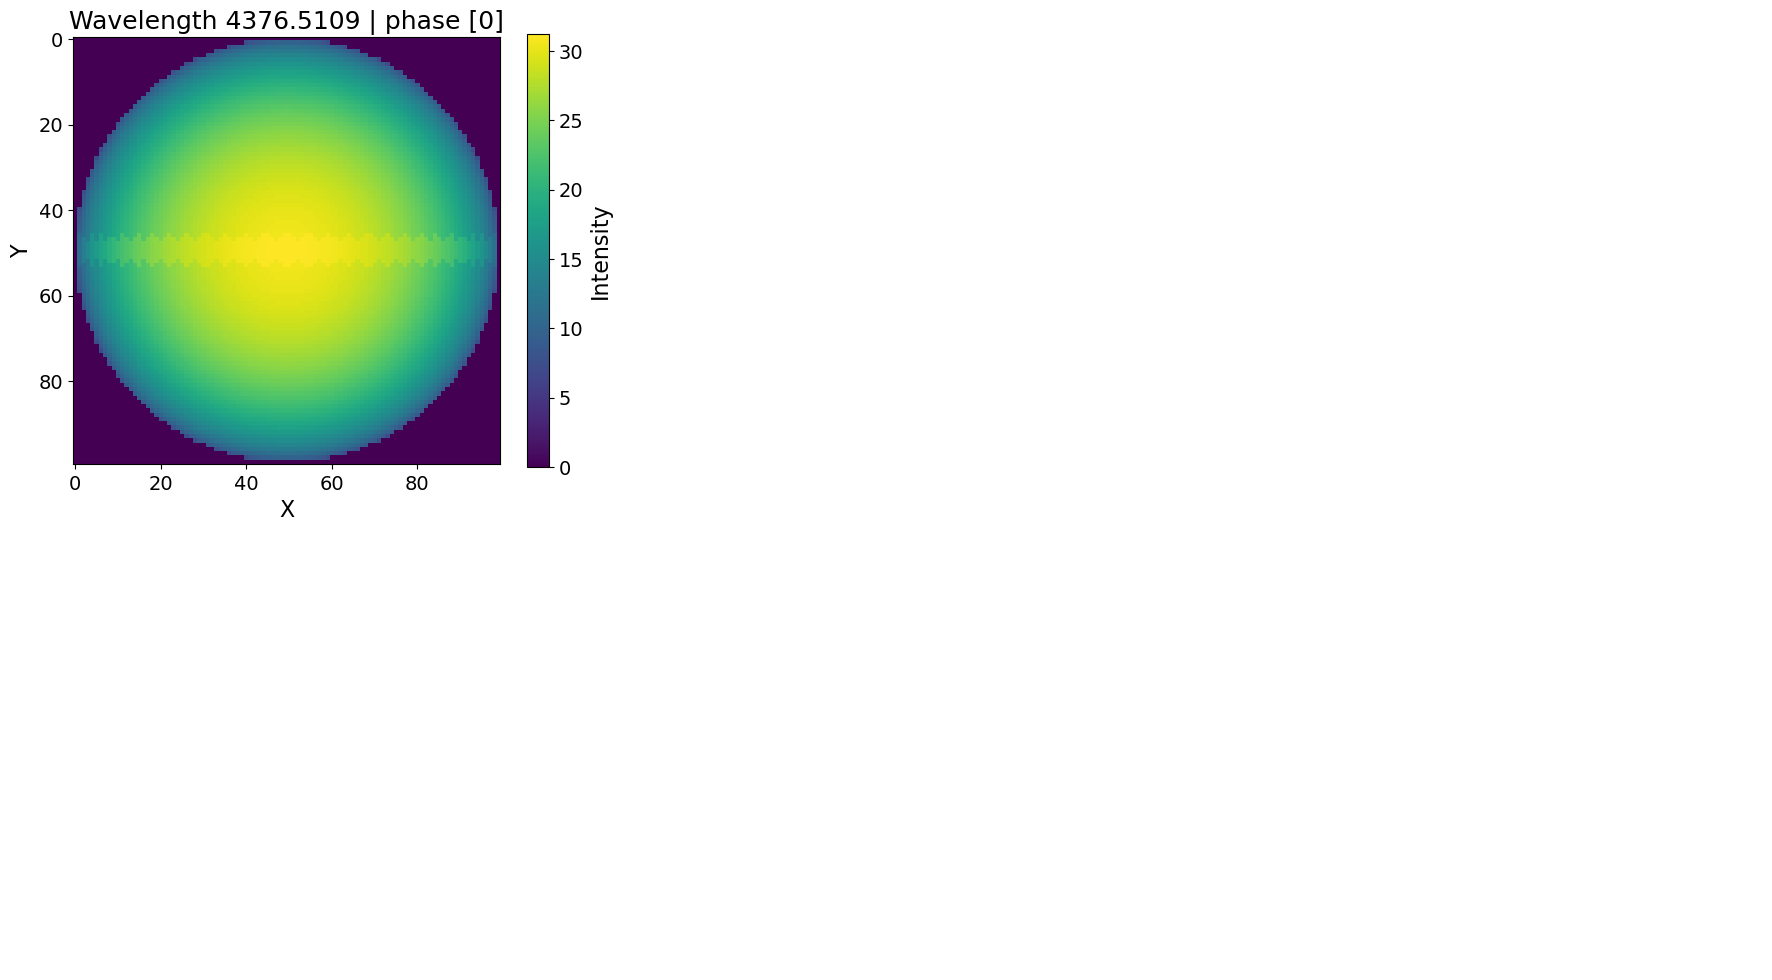

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'lines.markersize': 8
})


directory = './1_4376.5109_4377.4913_fac_lat0_long0_r0_v2000/'
directory = './1_div2fac_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/'
directory = './1_200G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000_i5/'
directory = './1_200G_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/'




# print the header of the first file to get the simulation parameters
first_csv = next(Path('.').glob(f'{directory}/wavelength_shifts_inp*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip())
        print(' ')
else:
    print("No .csv files found to read the header from.")

# Find all intensity-map files
npy_files = sorted(Path('.').glob(f'{directory}/disk_inp*.npy'))
if not npy_files:
    raise FileNotFoundError("No files found matching pattern: disk_inp*.npy")

def parse_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.npy$', p.name)
    return float(m.group(1)) if m else np.nan

# Load all files into a dict: {wavelength: array}
intensity_maps = {}
for f in npy_files:
    wl = parse_wavelength(f)
    intensity_maps[wl] = np.load(f)

print(f"Loaded {len(intensity_maps)} files")
# for wl in sorted(intensity_maps):
#     print(f"  {wl}: shape={intensity_maps[wl].shape}")

# Optional: stack to one array if all shapes are identical
shapes = {arr.shape for arr in intensity_maps.values()}
if len(shapes) == 1:
    wavelengths = np.array(sorted(intensity_maps.keys()))
    all_intensity_maps = np.stack([intensity_maps[wl] for wl in wavelengths], axis=0)
    # all_intensity_maps shape: (num_wavelengths, num_phases, H, W)
    print("Stacked shape (Wavelength, Phase, H, W):", all_intensity_maps.shape)
else:
    print("Shapes differ across files; kept as dictionary in 'intensity_maps'.")


# Quick plot for one wavelength (first one)
plot_wl = sorted(intensity_maps.keys())[0]
indices = range(0, min(51, intensity_maps[plot_wl].shape[0]), 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, idx in zip(axes, indices):
    img_data = intensity_maps[plot_wl][idx]
    im = ax.imshow(img_data, cmap='viridis')
    

    ax.set_title(f'Wavelength {plot_wl} | phase [{idx}]')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    fig.colorbar(im, ax=ax, label='Intensity')

for ax in axes[len(list(indices)):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Loaded shift maps: 57
wavelength_shifts_all shape (Wavelength, H, W): (57, 100, 100)
Maximum wavelength shift: 0.05753400351038564
Minimum wavelength shift: -0.05753400351038564


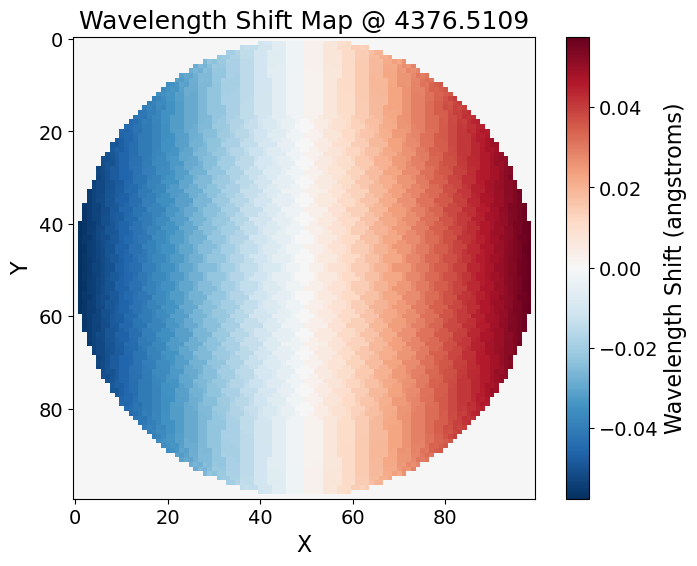

In [10]:
# Load wavelength shift maps for all wavelengths

shift_files = sorted(Path('.').glob(f'{directory}/wavelength_shifts_inp*.csv'))
if not shift_files:
    raise FileNotFoundError("No files found matching pattern: wavelength_shifts_inp*.csv")

def parse_shift_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.csv$', p.name)
    return float(m.group(1)) if m else np.nan

wavelength_shifts_by_wl = {}
for f in shift_files:
    wl = parse_shift_wavelength(f)
    wavelength_shifts_by_wl[wl] = np.loadtxt(f)

# Keep same wavelength order as intensity data (from Cell 0)
missing = [wl for wl in wavelengths if wl not in wavelength_shifts_by_wl]
if missing:
    raise ValueError(f"Missing shift maps for wavelengths: {missing}")

wavelength_shifts_all = np.stack([wavelength_shifts_by_wl[wl] for wl in wavelengths], axis=0)
print("Loaded shift maps:", len(wavelength_shifts_by_wl))
print("wavelength_shifts_all shape (Wavelength, H, W):", wavelength_shifts_all.shape)

print(f"Maximum wavelength shift: {wavelength_shifts_all.max()}")
print(f"Minimum wavelength shift: {wavelength_shifts_all.min()}")

# Optional quick check plot (first wavelength)
plt.figure(figsize=(8, 6))
plt.imshow(wavelength_shifts_all[0], cmap='RdBu_r')
plt.colorbar(label='Wavelength Shift (angstroms)')
plt.title(f'Wavelength Shift Map @ {wavelengths[0]}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()



In [4]:
# Combine per wavelength using dictionaries to guarantee correct matching
# intensity_maps[inp_wl] -> (Phase, H, W)
# wavelength_shifts_by_wl[inp_wl] -> (H, W)
# area_weight -> (H, W)
all_maps_with_shift_by_inp_wl = {
    inp_wl: np.stack(
        [
            intensity_maps[inp_wl],
            np.broadcast_to(wavelength_shifts_by_wl[inp_wl], intensity_maps[inp_wl].shape),
        ],
        axis=-1
    )
    for inp_wl in sorted(intensity_maps)
}

print("Built entries:", len(all_maps_with_shift_by_inp_wl))
first_wl = sorted(all_maps_with_shift_by_inp_wl)[0]
print(f"Example @ {first_wl}:", all_maps_with_shift_by_inp_wl[first_wl].shape)
print("Per-wavelength shape: (Phase, H, W, C), channels: 0=intensity, 1=wavelength_shift_in_m")

Built entries: 57
Example @ 4376.5109: (1, 100, 100, 2)
Per-wavelength shape: (Phase, H, W, C), channels: 0=intensity, 1=wavelength_shift_in_m


[4376.5109 4376.5284 4376.5459 4376.5634 4376.5809 4376.5984 4376.6159
 4376.6334 4376.6509 4376.6684 4376.6859 4376.7034 4376.721  4376.7385
 4376.756  4376.7735 4376.791  4376.8085 4376.826  4376.8435 4376.861
 4376.8785 4376.896  4376.9135 4376.931  4376.9485 4376.9661 4376.9836
 4377.0011 4377.0186 4377.0361 4377.0536 4377.0711 4377.0886 4377.1061
 4377.1236 4377.1411 4377.1586 4377.1762 4377.1937 4377.2112 4377.2287
 4377.2462 4377.2637 4377.2812 4377.2987 4377.3162 4377.3337 4377.3512
 4377.3688 4377.3863 4377.4038 4377.4213 4377.4388 4377.4563 4377.4738
 4377.4913]


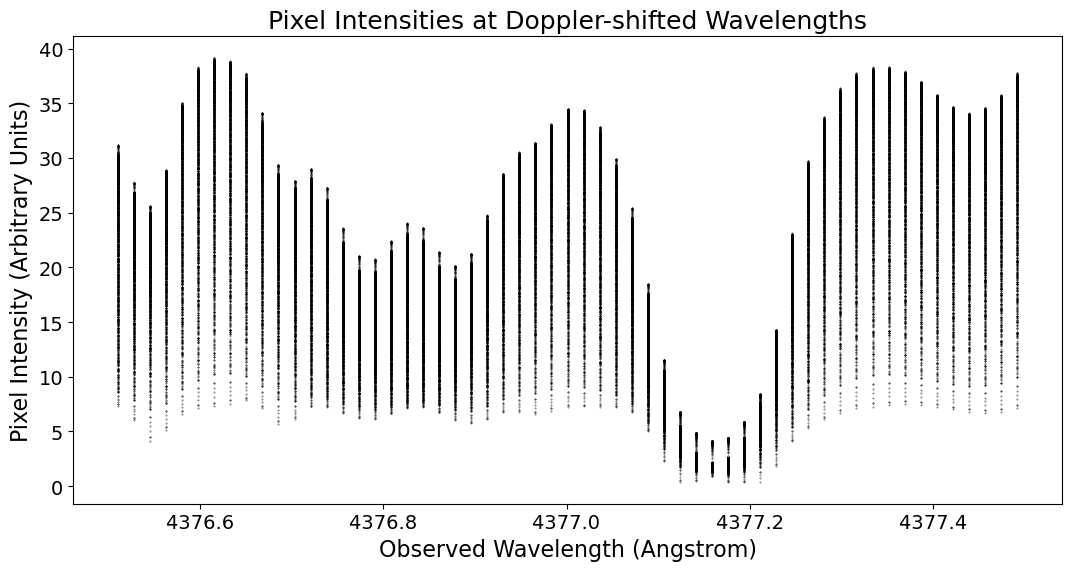

Phase index: 0
Num pixel points: 437052
Shift range in plot units: 4376.5109 to 4377.4913


In [5]:
# Phase-0 spectrum from per-pixel Doppler-shifted wavelengths
# No binning: each pixel is plotted at its own shifted wavelength
# Uses: all_maps_with_shift_by_inp_wl[inp_wl] with shape (Phase, H, W, 3)
# channel 0 = intensity, channel 1 = wavelength shift (meters), channel 2 = pixel weight

phase_idx = 0
wl_grid = np.array(sorted(all_maps_with_shift_by_inp_wl.keys()), dtype=float)
print(wl_grid)

# Convert shift map into the same wavelength units used by the filenames
# Current filenames appear to be in Angstrom, while the shift map is in meters.

shift_scale = 1
x_label = 'Observed Wavelength (Angstrom)'

shifted_lambda_all = []
intensity_all = []

for inp_wl in wl_grid:
    arr = all_maps_with_shift_by_inp_wl[inp_wl]
    intensity_2d = arr[phase_idx, :, :, 0]
    dlam_2d = arr[phase_idx, :, :, 1] * shift_scale

    # Apply pixel weighting to intensity
    intensity_2d = intensity_2d #* weight_2d


    # Pixel-contributed observed wavelength for this bin center
    lam_obs = inp_wl + dlam_2d

    # Keep only on-disk / emitting pixels
    m = intensity_2d > 0
    shifted_lambda_all.append(lam_obs[m].ravel())
    intensity_all.append(intensity_2d[m].ravel())

shifted_lambda_all = np.concatenate(shifted_lambda_all)
intensity_all = np.concatenate(intensity_all)

plt.figure(figsize=(11, 6))
plt.scatter(shifted_lambda_all, intensity_all, s=.1, alpha=0.1, color='black')
plt.xlabel(x_label)
plt.ylabel('Pixel Intensity (Arbitrary Units)')
plt.title('Pixel Intensities at Doppler-shifted Wavelengths')
plt.tight_layout()

plt.savefig('phase0_pixel_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print('Phase index:', phase_idx)
print('Num pixel points:', shifted_lambda_all.size)
print('Shift range in plot units:', shifted_lambda_all.min(), 'to', shifted_lambda_all.max())



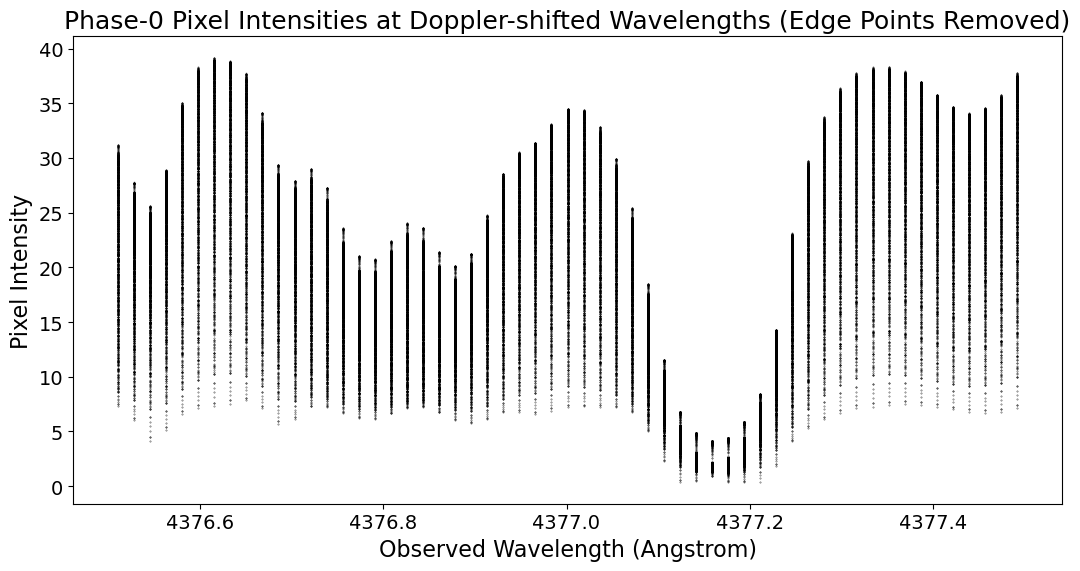

Points removed: 0
Remaining points: 437052
New wavelength range: 4376.5109 to 4377.4913


In [6]:
# Remove points near the edges (shifted_lambda_all +/- max wavelength shift)
max_shift = wavelength_shifts_all.max()
wl_min_edge = wavelengths.min() + max_shift
wl_max_edge = wavelengths.max() - max_shift

# Filter out edge points
valid_mask = (shifted_lambda_all >= wl_min_edge) & (shifted_lambda_all <= wl_max_edge)
shifted_lambda_filtered = shifted_lambda_all[valid_mask]
intensity_filtered = intensity_all[valid_mask]

# Replot without edge points
plt.figure(figsize=(11, 6))
plt.scatter(shifted_lambda_filtered, intensity_filtered, s=.1, alpha=0.1, color='black')
plt.xlabel(x_label)
plt.ylabel('Pixel Intensity')
plt.title('Phase-0 Pixel Intensities at Doppler-shifted Wavelengths (Edge Points Removed)')
plt.tight_layout()
plt.show()

print('Points removed:', shifted_lambda_all.size - shifted_lambda_filtered.size)
print('Remaining points:', shifted_lambda_filtered.size)
print('New wavelength range:', shifted_lambda_filtered.min(), 'to', shifted_lambda_filtered.max())

7668 points in bin 0 centered at 4376.5284
delta lambda: 0.017
7668 points in bin 1 centered at 4376.5459
delta lambda: 0.017
7668 points in bin 2 centered at 4376.5634
delta lambda: 0.017
7668 points in bin 3 centered at 4376.5809
delta lambda: 0.017
7668 points in bin 4 centered at 4376.5984
delta lambda: 0.017
7668 points in bin 5 centered at 4376.6159
delta lambda: 0.017
7668 points in bin 6 centered at 4376.6334
delta lambda: 0.017
7668 points in bin 7 centered at 4376.6509
delta lambda: 0.017
7668 points in bin 8 centered at 4376.6684
delta lambda: 0.017
7668 points in bin 9 centered at 4376.6859
delta lambda: 0.018
7668 points in bin 10 centered at 4376.7034
delta lambda: 0.018
7668 points in bin 11 centered at 4376.721
delta lambda: 0.018
7668 points in bin 12 centered at 4376.7385
delta lambda: 0.017
7668 points in bin 13 centered at 4376.756
delta lambda: 0.017
7668 points in bin 14 centered at 4376.7735
delta lambda: 0.017
7668 points in bin 15 centered at 4376.791
delta lam

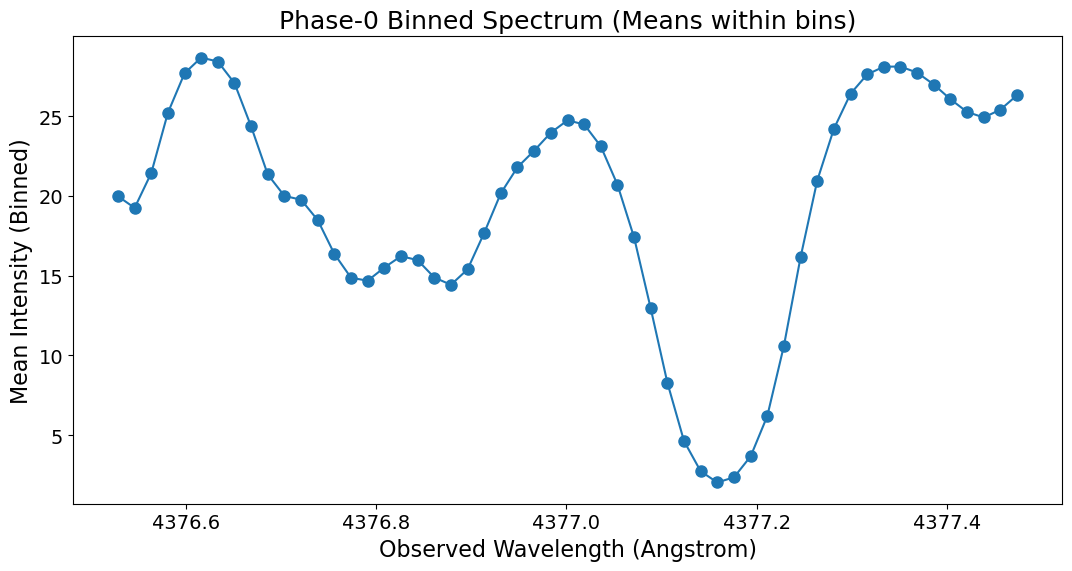

Number of bins: 55
Bin range: 4376.528 to 4377.474
Overall Mean intensity: 19.35


In [7]:
# Bin across same wavelengths as input files
bin_centers = wavelengths

# Create edges at midpoints between consecutive bin centers (list comprehension)
midpoints = [(bin_centers[i] + bin_centers[i + 1]) / 2 for i in range(len(bin_centers) - 1)]

# Extrapolate outer edges using the first/last half-spacing
left_edge = bin_centers[0] - (midpoints[0] - bin_centers[0])
right_edge = bin_centers[-1] + (bin_centers[-1] - midpoints[-1])

bin_edges = np.array([left_edge, *midpoints, right_edge], dtype=float)

# Remove bins at the edges where shift correction is incomplete
# Only include bins whose edges are at least max_shift away from the edge of the data
valid_bins_mask = (bin_edges[:-1] >= (wavelengths.min() + max_shift)) & (bin_edges[1:] <= (wavelengths.max() - max_shift))

bin_centers = bin_centers[valid_bins_mask]
valid_indices = np.where(valid_bins_mask)[0]

# Bin the scattered data only for valid bins
binned_intensity = np.zeros(len(bin_centers))
for i, idx in enumerate(valid_indices):
    mask = (np.round(shifted_lambda_filtered, 10) >= np.round(bin_edges[idx], 10)) & (np.round(shifted_lambda_filtered, 10) < np.round(bin_edges[idx + 1], 10))
    if mask.any():
        binned_intensity[i] = intensity_filtered[mask].sum()  / len(intensity_filtered[mask]) #* (4.95/5)**2 * np.pi /4
        print(len(intensity_filtered[mask]), 'points in bin', i, 'centered at', bin_centers[i])
        print(f'delta lambda: {bin_edges[idx+1] - bin_edges[idx]:.3f}')
       # print(f'delta nu: {(3e8 / (bin_edges[idx] * 1e-10)) - (3e8 / (bin_edges[idx+1] * 1e-10))} Hz')
    
# Plot binned spectrum
plt.figure(figsize=(11, 6), dpi=100)
plt.plot(bin_centers, binned_intensity, marker='o', linestyle='-', linewidth=1.5)
plt.xlabel(x_label)
plt.ylabel('Mean Intensity (Binned)')
plt.title('Phase-0 Binned Spectrum (Means within bins)')
plt.tight_layout()
#plt.xlim(4375.9, 4376.1)
plt.show()

print(f'Number of bins: {len(bin_centers)}')
if len(bin_centers) > 0:
    print(f'Bin range: {bin_centers[0]:.3f} to {bin_centers[-1]:.3f}')
    print(f'Overall Mean intensity: {np.nanmean(binned_intensity):.2f}')
else:
    print('No valid bins found after edge removal.')

[]


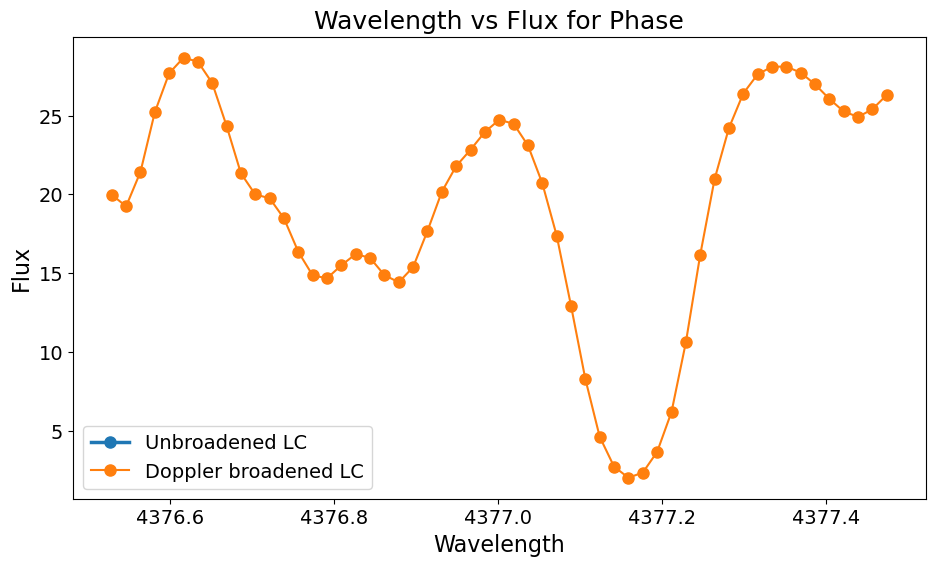

In [8]:
import glob 
phase_indices = [0] 
file_list = sorted(glob.glob(f'../lightcurves/{directory}/*.csv'))
file_list = file_list#[::2]
print(file_list)

# Extract wavelengths once
wavelengths = []
all_flux = {phase: [] for phase in phase_indices}
for fname in file_list:
    data = np.loadtxt(fname)
    data = np.atleast_1d(data) # Ensure data is at least 1D to avoid len() errors on scalars
    
    wavelength = float(fname[-13:-4])
    print(wavelength)
    wavelengths.append(wavelength)
    
    for phase in phase_indices:
        if phase < len(data):
            all_flux[phase].append(data[phase])
        else:
            all_flux[phase].append(np.nan)  # handle out-of-range safely

wavelengths = np.array(wavelengths)

# Sort by wavelength
sort_idx = np.argsort(wavelengths)
wavelengths = wavelengths[sort_idx]

plt.figure(figsize=(11, 6), dpi=100)

for phase in phase_indices:
    flux_array = np.array(all_flux[phase])[sort_idx]
    plt.plot(wavelengths, flux_array, marker='o', label=f'Unbroadened LC')
    plt.plot(bin_centers, binned_intensity, marker='o', linestyle='-', linewidth=1.5, label='Doppler broadened LC')


plt.xlabel('Wavelength')
plt.ylabel('Flux')
plt.title('Wavelength vs Flux for Phase')
plt.legend()
# plt.xlim(4375.9, 4376.1)
plt.show()